<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
!pip install bertopic
!pip install tweet-preprocessor

In [ ]:
from google.colab import drive

import pandas as pd
import matplotlib.pyplot as plt

import re

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from pysentimiento.preprocessing import preprocess_tweet

# Load Data

## Connect to Goole Drive


In [ ]:
# Connect to Goole Drive to use the data.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Labeled Datasets for Research on Information Operations.

In [ ]:
file_path = "/content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_3.gzip.parquet"

df = pd.read_parquet(file_path)

In [ ]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
100000,43394c24c54037f763e8318026ffba9aeb9317f672,"Queda prohibido no sonreir a los problemas, no...",2727201c363b6fc4afe259ba4094ae0c49cb4df224,None,None,None,2013-02-21 16:02:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,True,5ff80261b935621244fb38fff05231bf108ba8a488,4af2ce0fdafbc22f1a0be317a2f1025f2b18983194,[],[],[5ff80261b935621244fb38fff05231bf108ba8a488],False
100001,1b6cb8bafe65e8b9e639b7e52075c8ebf34d854d6c,"Te encontraras con gente hipócrita, con amigos...",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-02-21 16:04:04,8949eab1b3f746ed66a069ae5d6c415a57dc546ffc,Agradecida con Dios y con la Vida. Ahora en #...,471,233,2010-08-25,False,None,None,[],[],[],True
100002,4b69e40a8e23031f7ddc3832dfe5f289e851b56299,Aventarle un diccionario a alguien en la cabez...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-02-21 16:04:12,8949eab1b3f746ed66a069ae5d6c415a57dc546ffc,Agradecida con Dios y con la Vida. Ahora en #...,471,233,2010-08-25,False,None,None,[],[],[],True
100003,f810b69a925e539fb18b86ad0d227751cf072738bd,"Suena mi alarma del celu, tendre que levantarm...",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-02-21 16:04:16,8949eab1b3f746ed66a069ae5d6c415a57dc546ffc,Agradecida con Dios y con la Vida. Ahora en #...,471,233,2010-08-25,True,7e6b7dd1aa865b143fc37f4181e392613d1e6dfe3f,e6e93d6dcfdca0ea6ba2104dc6532ade3f85263147,[],[],[7e6b7dd1aa865b143fc37f4181e392613d1e6dfe3f],True
100004,94e00228f2ac99ef8ae06ab1c5419e74dfd7dc4699,En el mar la vida es mas sabrosa 8' @5b3c3e3a2...,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2013-02-21 16:15:00,4a08f9f3e1b73d62e982f899cdfb644e2101bd28a4,Grateful💕,587,270,2010-06-06,True,ad1f5918aa283b31785d589c2ade1c1ca176a23a47,4e9a2c4ec3f5bb6ec24e2936e287ac2fa33b30245d,[],[https://f87702c9a584719155693093bf96b50d218e8...,"[ad1f5918aa283b31785d589c2ade1c1ca176a23a47, 5...",False


## Dataset Statistics

In [ ]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts().head())

df shape:                                (50000, 19)
df posts with hashtags # shape:          (22419, 19)  (44.84%)
df posts with account_mentions @ shape:  (31089, 19)  (62.18%)
df posts with urls shape:                (18968, 19)  (37.94%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control          

# Clean Text

In [ ]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"^https?://", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [ ]:
def clean_english_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"https?://\S+|www\.\S+", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # Remove non english-letters/numbers/underscore
    text = re.sub(r"[^0-9a-zA-Z_]+", " ", text)

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [ ]:
df["clean_post_text"] = df["post_text"].apply(clean_english_text)

In [ ]:
df[["post_text","clean_post_text"]].head(30)

,post_text,clean_post_text
100000,"Queda prohibido no sonreir a los problemas, no...",queda prohibido no sonreir a los problemas no ...
100001,"Te encontraras con gente hipócrita, con amigos...",te encontraras con gente hip crita con amigos ...
100002,Aventarle un diccionario a alguien en la cabez...,aventarle un diccionario a alguien en la cabez...
100003,"Suena mi alarma del celu, tendre que levantarm...",suena mi alarma del celu tendre que levantarme...
100004,En el mar la vida es mas sabrosa 8' @5b3c3e3a2...,en el mar la vida es mas sabrosa 8 MENTION_5b3...
100005,"—Abue, ¿por qué tienes la boca tan grande? —Tú...",abue por qu tienes la boca tan grande t abueli...
100006,Ver fotos del pasado.. recordar y llorar por e...,ver fotos del pasado recordar y llorar por esa...
100007,@597739f6dae7bf858889e6e3d126ae99e935ee9415 ja...,MENTION_597739f6dae7bf858889e6e3d126ae99e935ee...
100008,Tengo mi sonrisa lista para cuando te vea.,tengo mi sonrisa lista para cuando te vea
100009,"Si quieres saber donde está tu corazón, mira d...",si quieres saber donde est tu coraz n mira don...


# English Topic Clustering

In [ ]:
def english_topic_modeling(posts_text_lst, min_topic_size=120):

    embedding_model = SentenceTransformer("digio/Twitter4SSE")

    topic_model = BERTopic(
        embedding_model=embedding_model,
        language="english",
        min_topic_size=min_topic_size,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(posts_text_lst)

    return topics, probs, topic_model

In [ ]:
english_df = df[df["post_language"] == "en"].head(200).copy()

posts_text_lst = english_df["clean_post_text"].to_list()

print(f"english_df shape: {english_df.shape}")

topics, probs, topic_model = english_topic_modeling(posts_text_lst,min_topic_size=3)

english_df["topic"] = topics

english_df shape: (200, 19)


2025-11-13 11:25:08,451 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

2025-11-13 11:25:54,237 - BERTopic - Embedding - Completed ✓
2025-11-13 11:25:54,240 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-13 11:25:54,765 - BERTopic - Dimensionality - Completed ✓
2025-11-13 11:25:54,766 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-13 11:25:54,783 - BERTopic - Cluster - Completed ✓
2025-11-13 11:25:54,787 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-13 11:25:54,808 - BERTopic - Representation - Completed ✓


In [ ]:
topic_count = topic_model.get_topic_info()
topic_count

,Topic,Count,Name,Representation,Representative_Docs
0,0,90,0_rt_the_https_to,"[rt, the, https, to, my, it, on, you, of, for]",[😩RT @91b8a5775cf58fa6d6a8defe373d5644eb62f881...
1,1,84,1_me_to_you_the,"[me, to, you, the, that, be, my, get, in, and]","[I Don't Want No Scrub, A Scrub Is A Guy That ..."
2,2,14,2_cancer_03d691699fd4508b58fd930f2e8e8b17f6352...,"[cancer, 03d691699fd4508b58fd930f2e8e8b17f6352...",[“@03d691699fd4508b58fd930f2e8e8b17f6352591e2:...
3,3,12,3_meirc_training_dubai_uae,"[meirc, training, dubai, uae, https, managemen...",[The Certified Negotiator https://5d471d488d1...


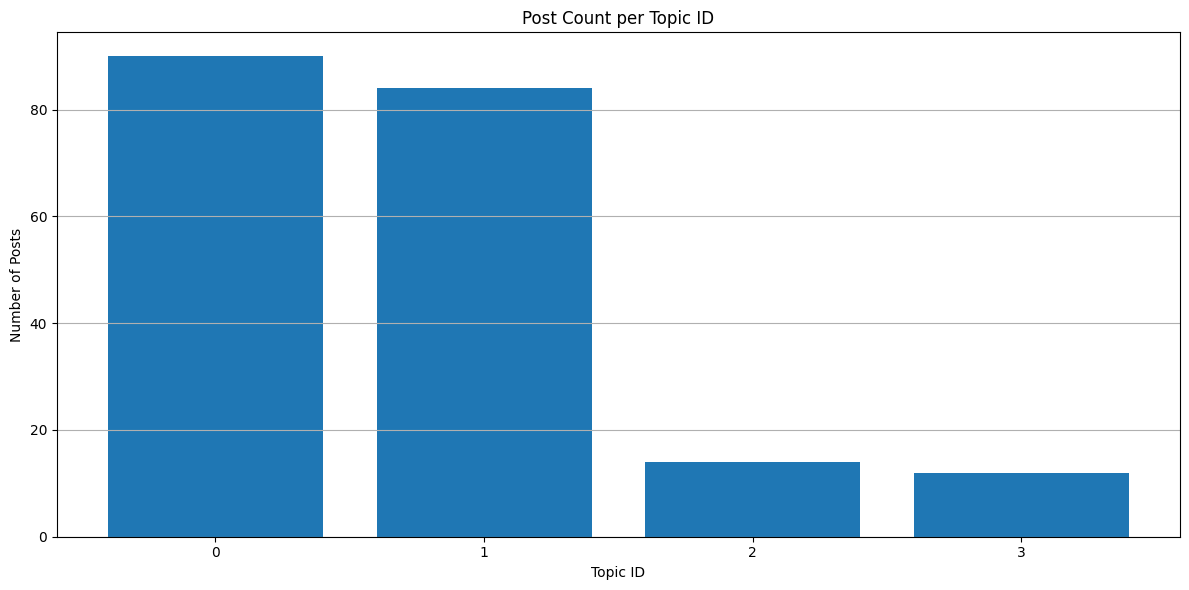

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(topic_count.Topic, topic_count.Count)
plt.xlabel("Topic ID")
plt.ylabel("Number of Posts")
plt.title("Post Count per Topic ID")
plt.grid(axis='y')
plt.xticks(topic_count.Topic)
plt.tight_layout()
plt.show()

In [ ]:
topic_model.visualize_topics(custom_labels=True)

In [ ]:
topic_model.visualize_hierarchy()

